Question 1

a) A p-value > 0.05 on joint-f test means that our data lacks evidence to prove these variables have a collective impact. Given the p-value is outside of acceptable range, I do agree that at this point, it does not make sense to look at the rest of the regression output. Proceeding with looking at variable t-tests would be in vain since any individual relationship could be fluke. However, calling the model plain crap is harsh, and unnecesarry. I would recommend going back to the drawing board to see what could have gone wrong. It could be the data set is too small, or corrupt, or had some serious outliers. It could also be that there is multicollinearity which needs us to adjust our variables. Lastly, there is a chance the person deciding the variables lacked business aptitude and missed on some key items to include.

b) Blanket replacing an outlier with the set average seems like a very bad idea. As you can imagine, this would distort business reality for the model, leading to heavier influence towards the average and less towards the true extreamities observed in business practice. This means higher confidence, i.e. lower standard error on an incorrect model - a recipe for disaster. Instead, I would recommend we try to understand the nature of the outlier. If the outlier is a confirmed error or out of scope of the analysis, it is safe to delete it rather than mask it with the average. If it is in scope, best approach is to keep it as is. In the scenario that an outlier is actually corrupted data, we could use the multiple imputation approach to repopulate it.

c) Alpha should not be always set to 0.05. This should be a business driven decision. A better rule of thumb would be when an activity is high risk/high cost choose lower alpha (protects from type I error) and when an activity is low risk/low cost, choose higher alpha to minimize missed opportunity (type II error). However, important to note that in business rarely things are as clear as that and its often best to individually evaluate each item to set an appropriate alpha.

d) I think scrapping the data is unnecesarry. Case dependent we can run White's test or more likely the Breusch-Pagan test that has higher statistical power and should be viable here with limited variables (assuming limited variables given I cannot imagine a complex model coming out of a weekend customer satisfaction survey). In both tests, the null hypothesis is homoskedasticity. If the printed p-value is below 0.05, we reject the null and confirm heteroskedasticity is present. Once detected, we do not scrap the data. We fix the issue instantly by utilizing heteroskedasticity-robust standard errors such as White's correction. This adjusts our standard errors and makes our hypothesis testing reliable again without needing to rerun the survey.

In [ ]:
# Question 4

import pandas as pd
import numpy as np
import os.path as osp
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Import the data from the excel file
data_path = osp.join(osp.curdir, '860 Assignment 2 Data.xlsx')
data = pd.read_excel(data_path, sheet_name='Curry')

print(data.dtypes)
print(data.describe(include='all'))
# Given data is category to get more insights
print(data['Country'].value_counts())  

Obs            int64
Sales        float64
Ad_Budget    float64
Price        float64
Distance       int64
Country          str
dtype: object
               Obs         Sales   Ad_Budget       Price    Distance Country
count   200.000000    200.000000  200.000000  200.000000  200.000000     200
unique         NaN           NaN         NaN         NaN         NaN       2
top            NaN           NaN         NaN         NaN         NaN      US
freq           NaN           NaN         NaN         NaN         NaN     138
mean    100.500000  15816.903199  308.064200   10.137700   15.480000     NaN
std      57.879185   5152.695615  100.774668    2.168688    5.997453     NaN
min       1.000000   3679.158349   75.250000    4.150000    5.000000     NaN
25%      50.750000  11904.260933  241.302500    8.775000   11.000000     NaN
50%     100.500000  15843.110684  310.560000   10.055000   16.000000     NaN
75%     150.250000  19337.094804  383.385000   11.602500   21.000000     NaN
max     200.0

In [ ]:
# 4a

# Creating a model sales using all variables in the dataset
# C(Country) is used to tell statsmodel to dummy code Country. 
# Dummy coding happens in alphabetical order, assigning first country in alphabetical order a 0 
# In our case this is CA which will be the reference group.

model_a = ols('Sales ~ Ad_Budget + Price + Distance + C(Country)', data).fit()
print(model_a.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                     5049.
Date:                Tue, 21 Jul 2026   Prob (F-statistic):          1.25e-195
Time:                        22:19:15   Log-Likelihood:                -1527.8
No. Observations:                 200   AIC:                             3066.
Df Residuals:                     195   BIC:                             3082.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          591.7121    235.508  

In [18]:
# Testing predictive power of the model using F-stat and p-value
print("F-statistic:", model_a.fvalue, "p-value:", model_a.f_pvalue)
print("F is massive and p-value is very small, so we can reject the null hypothesis that all coefficients are jointly 0. The model as a whole has predictive power and we should proceed to the next test.")

F-statistic: 5049.1434788041215 p-value: 1.2480513096589891e-195
F is massive and p-value is very small, so we can reject the null hypothesis that all coefficients are jointly 0. The model as a whole has predictive power and we should proceed to the next test.


In [16]:
# Evaluating individual coefficients using t-stat and p-value
print("Ad_Budget, Price, and Country(US) are all significant. Distance is not with p = 0.13. However, I will leave it in the model since it seems relevant to the business question. I am assuming that distance here reflects how far an add was from location of sale.")

Ad_Budget, Price, and Country(US) are all significant. Distance is not with p = 0.13. However, I will leave it in the model since it seems relevant to the business question. I am assuming that distance here reflects how far an add was from location of sale.


In [30]:
# Lastly review R-squared and Adjusted R-squared to see how much of the variation in sales is explained by the model
print("R-squared:", model_a.rsquared, "Adj R-squared:", model_a.rsquared_adj)
print ("R-squared is 0.96, which means that 96% of the variation in sales is explained by the model. Adjusted R-squared is 0.95, which is very close to R-squared, indicating that the model is not overfitting.")

R-squared: 0.9904372266304324 Adj R-squared: 0.9902410671766977
R-squared is 0.96, which means that 96% of the variation in sales is explained by the model. Adjusted R-squared is 0.95, which is very close to R-squared, indicating that the model is not overfitting.


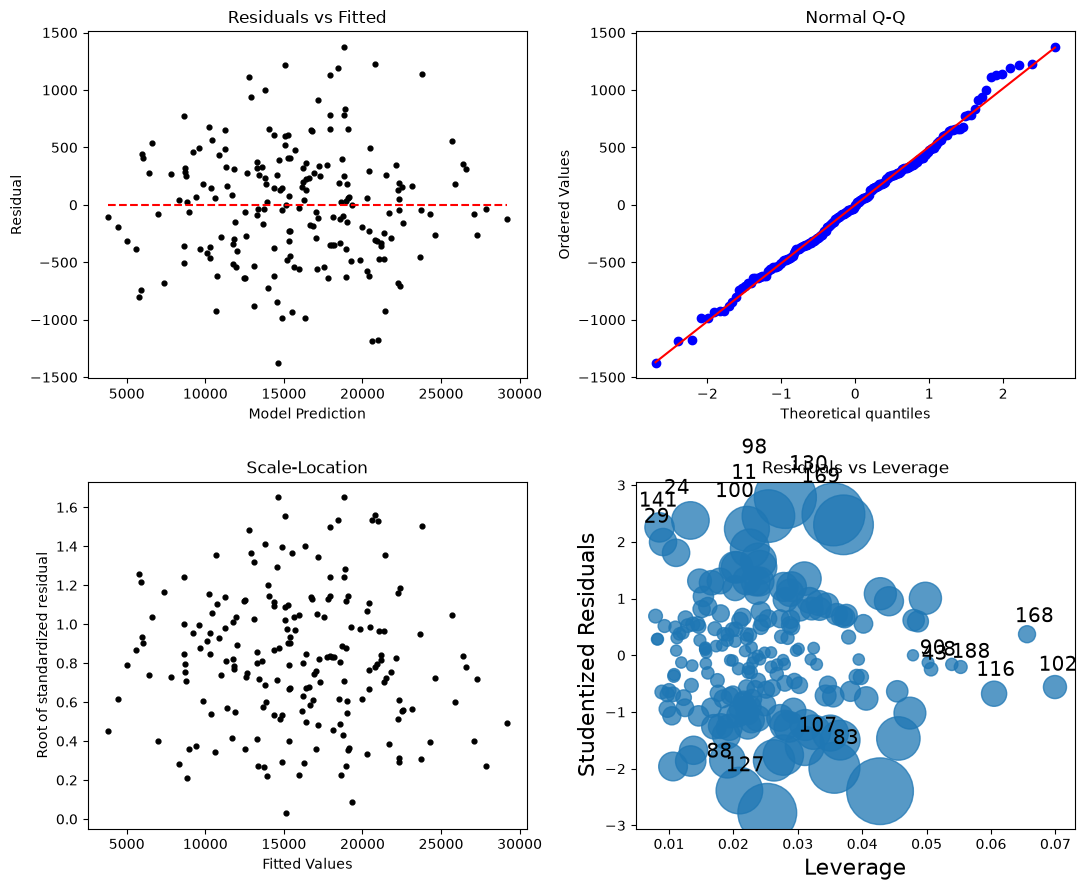

Residuals vs Fitted shows no pattern.
Normal Q-Q shows points more or less hugging the diagonal.
Scale-Location shows no pattern.
Residuals vs Leverage shows no concerning points with extremely high leverage.
All of these indicate that the model is a good fit for the data.


In [24]:
# Quick AI plotting to evaluate efficacy of the model.

predicted_y = model_a.fittedvalues
residuals = model_a.resid

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

# Residuals vs Fitted - look for absence of pattern, centered on 0
axes[0, 0].scatter(predicted_y, residuals, s=12, c='black')
axes[0, 0].hlines(0, predicted_y.min(), predicted_y.max(), color='red', linestyles='dashed')
axes[0, 0].set_xlabel("Model Prediction")
axes[0, 0].set_ylabel("Residual")
axes[0, 0].set_title("Residuals vs Fitted")

# Normal Q-Q - look for points hugging the diagonal
stats.probplot(residuals, dist='norm', plot=axes[0, 1])
axes[0, 1].set_title("Normal Q-Q")

# Scale-Location - look for a flat band (homoskedasticity)
norm_resid = (residuals - residuals.mean()) / residuals.std()
axes[1, 0].scatter(predicted_y, np.sqrt(np.abs(norm_resid)), c='black', s=12)
axes[1, 0].set_xlabel("Fitted Values")
axes[1, 0].set_ylabel("Root of standardized residual")
axes[1, 0].set_title("Scale-Location")

# Residuals vs Leverage / Cook's Distance
sm.graphics.influence_plot(model_a, ax=axes[1, 1], criterion="cooks")
axes[1, 1].set_title("Residuals vs Leverage")

plt.tight_layout()
plt.show()
print("Residuals vs Fitted shows no pattern.\nNormal Q-Q shows points more or less hugging the diagonal.\nScale-Location shows no pattern.\nResiduals vs Leverage shows no concerning points with extremely high leverage.\nAll of these indicate that the model is a good fit for the data.")

In [ ]:
# Numeric check for heteroskedasticity
from statsmodels.stats.diagnostic import het_breuschpagan
bp = het_breuschpagan(model_a.resid, model_a.model.exog)
print(dict(zip(('LM Stat', 'LM p-value', 'F Stat', 'F p-value'), bp)))
print("p-values well above 0.05, so we fail to reject homoskedasticity, no HC3 correction needed.")

{'LM Stat': np.float64(1.6575089801551313), 'LM p-value': np.float64(0.7984209123881452), 'F Stat': np.float64(0.4073941108992015), 'F p-value': np.float64(0.8031919187062835)}
p-values well above 0.05, so we fail to reject homoskedasticity, no HC3 correction needed.


In [ ]:
# VIF check
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_vif = model_a.model.exog
vif_data = pd.DataFrame({
    'variable': model_a.model.exog_names,
    'VIF': [variance_inflation_factor(X_vif, i) for i in range(X_vif.shape[1])]
})
print(vif_data)
print("All VIFs are roughly 1 (i.e. < 5) no multicollinearity problem between Ad_Budget, Price, Distance and Country.")

           variable        VIF
0         Intercept  42.812459
1  C(Country)[T.US]   1.016656
2         Ad_Budget   1.009430
3             Price   1.014102
4          Distance   1.024444
All VIFs are roughly 1 (i.e. < 5) no multicollinearity problem between Ad_Budget, Price, Distance and Country.


In [33]:
# 4b

# Given the claim is directional here, whether US consumers respond MORE to change in Ad_Budget we will use a one-tailed t-test. This will be the most powerful test in this case.
# We will use a new interaction term to test this hypothesis. It will effectively null out the effect of Ad_Budget for CA and test the effect of Ad_Budget for US. 
# If the coefficient is positive and significant, we can conclude that US consumers respond more to change in ad budget than CA consumers.

print("H0: (Ad_Budget x US)  <= 0 (US consumers respond the same or less to change in Ad_Budget than CA consumers)\nH1: (Ad_Budget x US)   > 0 (US consumers respond more to change in Ad_Budget than CA consumers)\n")

# Building new model. Using the same C(Country) technique to dummy code Country, and creating interaction term between Ad_Budget and C(Country)
model_b = ols('Sales ~ Ad_Budget + Price + Distance + C(Country) + Ad_Budget:C(Country)', data).fit()
print(model_b.summary())

H0: (Ad_Budget x US)  <= 0 (US consumers respond the same or less to change in Ad_Budget than CA consumers)
H1: (Ad_Budget x US)   > 0 (US consumers respond more to change in Ad_Budget than CA consumers)

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                     4036.
Date:                Tue, 21 Jul 2026   Prob (F-statistic):          6.26e-194
Time:                        23:27:30   Log-Likelihood:                -1527.3
No. Observations:                 200   AIC:                             3067.
Df Residuals:                     194   BIC:                             3086.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
     

In [37]:
# Evaluating the interaction term using t-stat and p-value

interaction_coef = 'Ad_Budget:C(Country)[T.US]'
t_stat = model_b.tvalues[interaction_coef]
p_two_tailed = model_b.pvalues[interaction_coef]

# Converting two-tailed p-value to one-tailed
# If t points in the direction of H1 (i.e. positive), halve the p-value
p_one_tailed = p_two_tailed / 2 if t_stat > 0 else 1 - p_two_tailed / 2

print("Interaction coefficient:", model_b.params[interaction_coef])
print("t-statistic:", t_stat)
print("One-tailed p-value:", p_one_tailed)
print("\nT is negative and the one-tailed p-value is quite large so we fail to reject H0.\nWe cannot conclude that US consumers respond more to change in Ad_Budget than CA consumers. In fact, the negative coefficient suggests that they respond less, but this is not statistically significant.")

Interaction coefficient: -0.7270847291392784
t-statistic: -0.9074636329657192
One-tailed p-value: 0.8173562521403326

T is negative and the one-tailed p-value is quite large so we fail to reject H0.
We cannot conclude that US consumers respond more to change in Ad_Budget than CA consumers. In fact, the negative coefficient suggests that they respond less, but this is not statistically significant.


In [38]:
# 4c

# Creating a dummy for Country and each interaction with Country
data['US'] = np.where(data['Country'] == 'US', 1, 0)
data['Ad_Budget_US'] = data['US'] * data['Ad_Budget']
data['Price_US'] = data['US'] * data['Price']
data['Distance_US'] = data['US'] * data['Distance']

# New model with the newly created dummy and interaction term. We will skip Country now that we have US.
model_c = ols(
    'Sales ~ Ad_Budget + Price + Distance + US + Ad_Budget_US + Price_US + Distance_US',
    data
).fit()
print(model_c.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                     2876.
Date:                Tue, 21 Jul 2026   Prob (F-statistic):          1.17e-190
Time:                        23:48:28   Log-Likelihood:                -1526.5
No. Observations:                 200   AIC:                             3069.
Df Residuals:                     192   BIC:                             3095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      125.0916    436.436      0.287   

In [39]:
# Running Chow test which is a joint Wald test to see if the dummy and interactions together are 0

chow_hypothesis = '(US = 0, Ad_Budget_US = 0, Price_US = 0, Distance_US = 0)'
chow_result = model_c.wald_test(chow_hypothesis)
print(chow_result)

<F test: F=array([[42.7717247]]), p=1.2614673800585217e-25, df_denom=192, df_num=4>


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


In [43]:
print("F is large and the p-value is far below 0.05.\nTherefore, we REJECT the null that US and Canada share the same regression equation. The two groups are different and should not be pooled.")
print("This might seem contraddictory to part b, however, it is important to note that the Chow test is a joint test across the delta parameters,\nwhile part b only tested the Ad_Budget slope in isolation. Comparing the two does not make sense.")

F is large and the p-value is far below 0.05.
Therefore, we REJECT the null that US and Canada share the same regression equation. The two groups are different and should not be pooled.
This might seem contraddictory to part b, however, it is important to note that the Chow test is a joint test across the delta parameters,
while part b only tested the Ad_Budget slope in isolation. Comparing the two does not make sense.
